# Comprehensive Backtests: All Models on Test Data

Evaluate trained models on **out-of-sample test data**:

**PPO Model:**
- PPO with `unified` reward (Sharpe - Drawdown - Turnover)

**Baseline Strategies (5 models):**
1. Equal Weight
2. Buy & Hold
3. Risk Parity
4. Momentum
5. Min Variance

**Test Period:** Completely held-out data not seen during training

**Key Outputs:**
- Performance metrics for all models
- Cumulative returns comparison
- Risk-adjusted metrics
- Portfolio weight analysis
- Final model ranking

## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import json
import warnings
from typing import Dict, List
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import config and RL system
from config import *
from rl_system import (
    PortfolioEnv, PortfolioMonitor,
    backtest_rl_agent, backtest_baseline,
    EqualWeight, BuyHold, RiskParity, Momentum, MinVariance
)

# Plotting setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

%matplotlib inline

print("✓ All imports successful")
print(f"✓ Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ All imports successful
✓ Timestamp: 2025-11-20 07:28:25


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 2. Configuration

In [2]:
# Setup output directory
OUTPUT_DIR_BACKTEST = PROJECT_ROOT / 'results' / 'backtests'
OUTPUT_DIR_BACKTEST.mkdir(parents=True, exist_ok=True)

# Define all models to test
PPO_REWARD_TYPES = ['log_return']  # Updated to match training
BASELINE_STRATEGIES = ['equal_weight', 'buy_hold', 'risk_parity', 'momentum', 'min_variance']

# Print configuration
print(f"{'='*80}")
print("BACKTEST CONFIGURATION")
print(f"{'='*80}")
print(f"\n📊 Test data: {TEST_PATH}")
print(f"📁 Models: {OUTPUT_DIR}")
print(f"💾 Results: {OUTPUT_DIR_BACKTEST}")
print(f"\n🎯 Parameters:")
print(f"   Initial capital:  ${INITIAL_CAPITAL:,.0f}")
print(f"   Transaction cost: {TRANSACTION_COST*10000:.1f} bps")
print(f"   Max weight:       {MAX_WEIGHT_PER_ASSET:.0%}")
print(f"   Rebalance freq:   {REBALANCE_FREQUENCY} weeks")
print(f"   Risk-free rate:   {RISK_FREE_RATE:.1%}")
print(f"\n🤖 Models to Test:")
print(f"   PPO variants: {len(PPO_REWARD_TYPES)} ({', '.join(PPO_REWARD_TYPES)})")
print(f"   Baselines: {len(BASELINE_STRATEGIES)} ({', '.join(BASELINE_STRATEGIES)})")
print(f"   Total models: {len(PPO_REWARD_TYPES) + len(BASELINE_STRATEGIES)}")
print(f"\n🎨 Features: {len(FEATURE_COLS)} features")
print(f"{'='*80}")

BACKTEST CONFIGURATION

📊 Test data: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/data/processed/test.parquet
📁 Models: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models
💾 Results: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests

🎯 Parameters:
   Initial capital:  $100,000
   Transaction cost: 25.0 bps
   Max weight:       40%
   Rebalance freq:   4 weeks
   Risk-free rate:   4.0%

🤖 Models to Test:
   PPO variants: 1 (log_return)
   Baselines: 5 (equal_weight, buy_hold, risk_parity, momentum, min_variance)
   Total models: 6

🎨 Features: 100 features


## 3. Load Test Data

In [3]:
# Load test data
print(f"\n📂 Loading test data...")
test_data = pd.read_parquet(TEST_PATH)
test_data[DATE_COL] = pd.to_datetime(test_data[DATE_COL])

print(f"\n✓ Test Data Loaded:")
print(f"  Samples: {len(test_data):,}")
print(f"  Date range: {test_data[DATE_COL].min().date()} to {test_data[DATE_COL].max().date()}")
print(f"  Periods: {test_data[DATE_COL].nunique()}")
print(f"  Duration: {(test_data[DATE_COL].max() - test_data[DATE_COL].min()).days / 7:.1f} weeks")
print(f"  Tickers: {', '.join(TICKERS)}")
print(f"  All features: {len(FEATURE_COLS)}")
print(f"\n⚠️  This is OUT-OF-SAMPLE data not seen during training!")


📂 Loading test data...

✓ Test Data Loaded:
  Samples: 798
  Date range: 2023-08-31 to 2025-10-30
  Periods: 114
  Duration: 113.0 weeks
  Tickers: NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
  All features: 100

⚠️  This is OUT-OF-SAMPLE data not seen during training!


## 4. Load PPO Models

Load best model from each PPO reward type (best fold per reward type).

In [4]:
def load_all_ppo_models(reward_type: str, top_n: int = None):
    """
    Load PPO models for given reward type from all folds.
    
    Parameters:
    -----------
    reward_type : str
        Reward type ('log_return')
    top_n : int, optional
        If specified, only return top N models by validation Sharpe
        
    Returns:
    --------
    list : List of dicts with model info, sorted by val_sharpe descending
    """
    model_dir = OUTPUT_DIR / f"ppo_{reward_type}"
    
    if not model_dir.exists():
        print(f"  ⚠️  Model directory not found: {model_dir}")
        return []
    
    # Find all fold directories
    fold_dirs = sorted([d for d in model_dir.iterdir() if d.is_dir() and d.name.startswith('fold_')])
    
    if not fold_dirs:
        print(f"  ⚠️  No fold directories found in {model_dir}")
        return []
    
    models = []
    
    for fold_dir in fold_dirs:
        fold_idx = int(fold_dir.name.split('_')[-1])
        model_path = fold_dir / 'best_model.zip'
        
        if not model_path.exists():
            print(f"  ⚠️  Model not found: {model_path}")
            continue
        
        # Get validation Sharpe from logs
        val_results_path = fold_dir / 'logs' / 'val_evaluations.csv'
        if val_results_path.exists():
            val_df = pd.read_csv(val_results_path)
            best_sharpe = val_df['sharpe_ratio'].max()
        else:
            best_sharpe = 0.0
        
        try:
            model = PPO.load(model_path)
            models.append({
                'model': model,
                'reward_type': reward_type,
                'fold': fold_idx,
                'val_sharpe': best_sharpe,
                'model_path': str(model_path)
            })
        except Exception as e:
            print(f"  ✗ Error loading fold {fold_idx}: {e}")
    
    # Sort by validation Sharpe (descending)
    models = sorted(models, key=lambda x: x['val_sharpe'], reverse=True)
    
    # Return top N if specified
    if top_n is not None:
        models = models[:top_n]
    
    return models

# Load all PPO models (or top 2)
print(f"\n{'='*80}")
print("LOADING PPO MODELS")
print(f"{'='*80}\n")

ppo_models = {}
TOP_N_MODELS = 2  # Test best 2 models from each reward type

for reward_type in PPO_REWARD_TYPES:
    print(f"Loading PPO with {reward_type} reward...")
    models_list = load_all_ppo_models(reward_type, top_n=TOP_N_MODELS)
    
    if models_list:
        for model_info in models_list:
            model_name = f"PPO_{reward_type}_fold{model_info['fold']}"
            ppo_models[model_name] = model_info
            print(f"  ✓ Fold {model_info['fold']}: Val Sharpe = {model_info['val_sharpe']:.3f}")
    else:
        print(f"  ✗ No models loaded for {reward_type}")
    print()

print(f"{'='*80}")
print(f"✓ Loaded {len(ppo_models)} PPO models (top {TOP_N_MODELS} per reward type)")
print(f"{'='*80}")


LOADING PPO MODELS

Loading PPO with log_return reward...
  ✓ Fold 1: Val Sharpe = 1.696
  ✓ Fold 0: Val Sharpe = 0.906

✓ Loaded 2 PPO models (top 2 per reward type)


## 5. Run Backtests: PPO Models

In [5]:
print(f"\n{'='*80}")
print("BACKTESTING PPO MODELS")
print(f"{'='*80}\n")

ppo_results = {}
ppo_errors = []

for model_name, model_info in ppo_models.items():
    print(f"Backtesting {model_name}...")
    
    try:
        result = backtest_rl_agent(
            model=model_info['model'],
            data=test_data,
            feature_cols=FEATURE_COLS,
            tickers=TICKERS,
            rebalance_frequency=REBALANCE_FREQUENCY,
            transaction_cost=TRANSACTION_COST,
            max_weight_per_asset=MAX_WEIGHT_PER_ASSET,
            reward_lookback=REWARD_LOOKBACK,
            initial_capital=INITIAL_CAPITAL,
            reward_type=model_info['reward_type'],
            seed=RANDOM_SEED,
            # Pass config parameters
            min_entropy=MIN_ENTROPY,
            max_turnover=MAX_TURNOVER,
            annualization_factor=ANNUALIZATION_FACTOR,
            risk_free_rate=RISK_FREE_RATE
        )
        
        result['model_type'] = 'PPO'
        result['reward_type'] = model_info['reward_type']
        result['train_fold'] = model_info['fold']
        result['val_sharpe'] = model_info['val_sharpe']
        
        ppo_results[model_name] = result
        
        print(f"  ✓ Completed successfully")
        print(f"    Test Sharpe: {result['stats']['sharpe_ratio']:.3f}")
        print(f"    Test Return: {result['stats']['total_return']:.2%}")
        print(f"    Final Value: ${result['stats']['portfolio_value']:,.2f}")
        
    except Exception as e:
        error_msg = f"{model_name} backtest failed: {str(e)}"
        ppo_errors.append(error_msg)
        print(f"  ✗ {error_msg}")
        import traceback
        traceback.print_exc()
    
    print()

print(f"{'='*80}")
print(f"✓ PPO BACKTESTS COMPLETE: {len(ppo_results)}/{len(ppo_models)} successful")
if ppo_errors:
    print(f"  Errors: {len(ppo_errors)}")
print(f"{'='*80}")


BACKTESTING PPO MODELS

Backtesting PPO_log_return_fold1...
  ✓ Completed successfully
    Test Sharpe: 0.089
    Test Return: 17.17%
    Final Value: $117,171.03

Backtesting PPO_log_return_fold0...
  ✓ Completed successfully
    Test Sharpe: -0.017
    Test Return: 7.74%
    Final Value: $107,740.45

✓ PPO BACKTESTS COMPLETE: 2/2 successful


## 6. Run Backtests: Baseline Strategies

In [6]:
print(f"\n{'='*80}")
print("BACKTESTING BASELINE STRATEGIES")
print(f"{'='*80}\n")

# Create baseline strategy objects
baseline_strategies = {
    'Equal Weight': EqualWeight(TICKERS, MAX_WEIGHT_PER_ASSET),
    'Buy & Hold': BuyHold(TICKERS, MAX_WEIGHT_PER_ASSET),
    'Risk Parity': RiskParity(TICKERS, MAX_WEIGHT_PER_ASSET, DATE_COL, REWARD_LOOKBACK),
    'Momentum': Momentum(TICKERS, MAX_WEIGHT_PER_ASSET, DATE_COL, REWARD_LOOKBACK),
    'Min Variance': MinVariance(TICKERS, MAX_WEIGHT_PER_ASSET, DATE_COL, REWARD_LOOKBACK)
}

baseline_results = {}
baseline_errors = []

for strategy_name, strategy in baseline_strategies.items():
    print(f"Backtesting {strategy_name}...")
    
    try:
        result = backtest_baseline(
            strategy=strategy,
            data=test_data,
            date_col=DATE_COL,
            tickers=TICKERS,
            rebalance_frequency=REBALANCE_FREQUENCY,
            transaction_cost=TRANSACTION_COST,
            initial_capital=INITIAL_CAPITAL,
            annualization_factor=ANNUALIZATION_FACTOR,
            risk_free_rate=RISK_FREE_RATE
        )
        
        result['model_type'] = 'Baseline'
        result['reward_type'] = 'N/A'
        
        baseline_results[strategy_name] = result
        
        print(f"  ✓ Sharpe: {result['stats']['sharpe_ratio']:6.3f} | "
              f"Return: {result['stats']['total_return']:7.2%} | "
              f"Value: ${result['stats']['portfolio_value']:>,.2f}")
        
    except Exception as e:
        error_msg = f"{strategy_name} backtest failed: {str(e)}"
        baseline_errors.append(error_msg)
        print(f"  ✗ {error_msg}")
        import traceback
        traceback.print_exc()
    
    print()

print(f"{'='*80}")
print(f"✓ BASELINE BACKTESTS COMPLETE: {len(baseline_results)}/{len(baseline_strategies)} successful")
if baseline_errors:
    print(f"  Errors: {len(baseline_errors)}")
print(f"{'='*80}")


BACKTESTING BASELINE STRATEGIES

Backtesting Equal Weight...
  ✓ Sharpe:  1.174 | Return: 121.27% | Value: $221,269.74

Backtesting Buy & Hold...
  ✓ Sharpe:  1.058 | Return: 115.90% | Value: $215,899.44

Backtesting Risk Parity...
  ✓ Sharpe:  1.133 | Return:  93.17% | Value: $193,174.92

Backtesting Momentum...
  ✓ Sharpe:  1.064 | Return: 120.71% | Value: $220,711.79

Backtesting Min Variance...
  ✓ Sharpe:  0.940 | Return:  79.43% | Value: $179,434.45

✓ BASELINE BACKTESTS COMPLETE: 5/5 successful


## 7. Combine Results & Calculate Metrics

In [7]:
# Combine all results
all_results = {**ppo_results, **baseline_results}

print(f"\n✓ Total successful backtests: {len(all_results)}/{len(PPO_REWARD_TYPES) + len(BASELINE_STRATEGIES)}")

# Calculate additional metrics
summary = []

for name, result in all_results.items():
    stats = result['stats']
    traj = result['trajectory']
    
    # Calculate turnover
    if len(traj['weights']) > 1:
        weights_array = np.array(traj['weights'])
        turnovers = np.abs(np.diff(weights_array, axis=0)).sum(axis=1)
        avg_turnover = turnovers.mean()
        max_turnover = turnovers.max()
    else:
        avg_turnover = 0.0
        max_turnover = 0.0
    
    # Calculate win rate
    returns = np.array(traj['returns'])
    win_rate = (returns > 0).sum() / len(returns) if len(returns) > 0 else 0.0
    
    # Calculate Calmar ratio (return / max drawdown)
    calmar = abs(stats['total_return'] / stats['max_drawdown']) if stats['max_drawdown'] != 0 else 0.0
    
    # Calculate Sortino ratio (downside deviation)
    downside_returns = returns[returns < 0]
    downside_std = np.std(downside_returns) if len(downside_returns) > 0 else 1e-8
    sortino = (np.mean(returns) / downside_std) * np.sqrt(ANNUALIZATION_FACTOR)
    
    # Get model info
    model_type = result.get('model_type', 'Unknown')
    reward_type = result.get('reward_type', 'N/A')
    val_sharpe = result.get('val_sharpe', None)
    
    summary.append({
        'Model': name,
        'Type': model_type,
        'Reward': reward_type,
        'Val Sharpe': val_sharpe,
        'Test Sharpe': stats['sharpe_ratio'],
        'Test Sortino': sortino,
        'Total Return': stats['total_return'],
        'Volatility': stats['volatility'],
        'Max Drawdown': stats['max_drawdown'],
        'Calmar Ratio': calmar,
        'Final Value': stats['portfolio_value'],
        'Avg Turnover': avg_turnover,
        'Max Turnover': max_turnover,
        'Win Rate': win_rate
    })

summary_df = pd.DataFrame(summary)

# Sort by Test Sharpe ratio (descending)
summary_df = summary_df.sort_values('Test Sharpe', ascending=False).reset_index(drop=True)
summary_df['Rank'] = range(1, len(summary_df) + 1)

# Reorder columns
cols = ['Rank', 'Model', 'Type', 'Reward', 'Val Sharpe', 'Test Sharpe', 'Test Sortino',
        'Total Return', 'Volatility', 'Max Drawdown', 'Calmar Ratio',
        'Final Value', 'Avg Turnover', 'Max Turnover', 'Win Rate']
summary_df = summary_df[cols]

print("\n✓ Metrics calculated")


✓ Total successful backtests: 7/6

✓ Metrics calculated


## 8. Performance Summary

In [8]:
print(f"\n{'='*100}")
print("TEST SET PERFORMANCE SUMMARY (OUT-OF-SAMPLE)")
print(f"{'='*100}\n")

# Display full summary
display(summary_df.style.format({
    'Val Sharpe': '{:.3f}',
    'Test Sharpe': '{:.3f}',
    'Test Sortino': '{:.3f}',
    'Total Return': '{:.2%}',
    'Volatility': '{:.2%}',
    'Max Drawdown': '{:.2%}',
    'Calmar Ratio': '{:.3f}',
    'Final Value': '${:,.2f}',
    'Avg Turnover': '{:.3f}',
    'Max Turnover': '{:.3f}',
    'Win Rate': '{:.2%}'
}).background_gradient(subset=['Test Sharpe'], cmap='RdYlGn'))

# Save summary
summary_path = OUTPUT_DIR_BACKTEST / 'backtest_summary_all_models.csv'
summary_df.to_csv(summary_path, index=False)
print(f"\n💾 Summary saved: {summary_path}")


TEST SET PERFORMANCE SUMMARY (OUT-OF-SAMPLE)



,Rank,Model,Type,Reward,Val Sharpe,Test Sharpe,Test Sortino,Total Return,Volatility,Max Drawdown,Calmar Ratio,Final Value,Avg Turnover,Max Turnover,Win Rate
0,1,Equal Weight,Baseline,N/A,nan,1.174,2.098,121.27%,27.73%,-33.10%,3.664,"$221,269.74",0.000,0.000,58.41%
1,2,Risk Parity,Baseline,N/A,nan,1.133,2.112,93.17%,23.21%,-28.96%,3.218,"$193,174.92",0.035,0.379,61.06%
2,3,Momentum,Baseline,N/A,nan,1.064,1.993,120.71%,30.47%,-36.47%,3.310,"$220,711.79",0.105,1.027,57.52%
3,4,Buy & Hold,Baseline,N/A,nan,1.058,1.898,115.90%,29.69%,-34.61%,3.349,"$215,899.44",0.030,0.081,57.52%
4,5,Min Variance,Baseline,N/A,nan,0.940,1.854,79.43%,24.36%,-33.80%,2.350,"$179,434.45",0.130,0.822,60.18%
5,6,PPO_log_return_fold1,PPO,log_return,1.696,0.089,0.309,17.17%,37.14%,-52.74%,0.326,"$117,171.03",0.234,1.966,50.89%
6,7,PPO_log_return_fold0,PPO,log_return,0.906,-0.017,0.248,7.74%,33.51%,-55.14%,0.140,"$107,740.45",0.279,1.976,48.21%



💾 Summary saved: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests/backtest_summary_all_models.csv


## 9. Key Findings

In [9]:
print(f"\n{'='*100}")
print("KEY FINDINGS")
print(f"{'='*100}\n")

# Best overall model
best_model = summary_df.iloc[0]
print(f"🏆 BEST MODEL ON TEST SET: {best_model['Model']}")
print(f"   Type: {best_model['Type']}")
if best_model['Type'] == 'PPO':
    print(f"   Reward: {best_model['Reward']}")
print(f"   Test Sharpe: {best_model['Test Sharpe']:.3f}")
print(f"   Test Return: {best_model['Total Return']:.2%}")
print(f"   Max Drawdown: {best_model['Max Drawdown']:.2%}")
print(f"   Final Value: ${best_model['Final Value']:,.2f}")

# Best PPO model
ppo_subset = summary_df[summary_df['Type'] == 'PPO']
if len(ppo_subset) > 0:
    best_ppo = ppo_subset.iloc[0]
    print(f"\n🤖 BEST PPO MODEL: {best_ppo['Model']}")
    print(f"   Reward Type: {best_ppo['Reward']}")
    print(f"   Test Sharpe: {best_ppo['Test Sharpe']:.3f}")
    print(f"   Val Sharpe: {best_ppo['Val Sharpe']:.3f}")
    print(f"   Rank: #{best_ppo['Rank']} overall")

# Best baseline
baseline_subset = summary_df[summary_df['Type'] == 'Baseline']
if len(baseline_subset) > 0:
    best_baseline = baseline_subset.iloc[0]
    print(f"\n📊 BEST BASELINE: {best_baseline['Model']}")
    print(f"   Test Sharpe: {best_baseline['Test Sharpe']:.3f}")
    print(f"   Rank: #{best_baseline['Rank']} overall")

# PPO vs Baseline comparison
if len(ppo_subset) > 0 and len(baseline_subset) > 0:
    ppo_wins = (ppo_subset['Rank'] < best_baseline['Rank']).sum()
    print(f"\n📈 PPO vs BASELINES:")
    print(f"   {ppo_wins}/{len(ppo_subset)} PPO models beat the best baseline")
    print(f"   Best PPO Sharpe: {ppo_subset['Test Sharpe'].max():.3f}")
    print(f"   Best Baseline Sharpe: {baseline_subset['Test Sharpe'].max():.3f}")
    print(f"   Difference: {ppo_subset['Test Sharpe'].max() - baseline_subset['Test Sharpe'].max():.3f}")
    
    if ppo_wins == len(ppo_subset):
        print(f"   ✅ All PPO models outperform best baseline!")
    elif ppo_wins > 0:
        print(f"   ⚠️  Some PPO models beat baselines")
    else:
        print(f"   ❌ Baselines outperform all PPO models")

# Reward type analysis
if len(ppo_subset) > 0:
    print(f"\n🎯 PPO REWARD TYPE RANKING:")
    for idx, row in ppo_subset.iterrows():
        print(f"   {row['Rank']}. {row['Reward']:20s} | Sharpe: {row['Test Sharpe']:.3f} | Return: {row['Total Return']:.2%}")

# Statistical summary
print(f"\n📊 OVERALL STATISTICS:")
print(f"   Models tested: {len(summary_df)}")
print(f"   PPO models: {len(ppo_subset)}")
print(f"   Baseline models: {len(baseline_subset)}")
print(f"   Mean Sharpe: {summary_df['Test Sharpe'].mean():.3f}")
print(f"   Std Sharpe: {summary_df['Test Sharpe'].std():.3f}")
print(f"   Range: [{summary_df['Test Sharpe'].min():.3f}, {summary_df['Test Sharpe'].max():.3f}]")

print(f"\n{'='*100}")


KEY FINDINGS

🏆 BEST MODEL ON TEST SET: Equal Weight
   Type: Baseline
   Test Sharpe: 1.174
   Test Return: 121.27%
   Max Drawdown: -33.10%
   Final Value: $221,269.74

🤖 BEST PPO MODEL: PPO_log_return_fold1
   Reward Type: log_return
   Test Sharpe: 0.089
   Val Sharpe: 1.696
   Rank: #6 overall

📊 BEST BASELINE: Equal Weight
   Test Sharpe: 1.174
   Rank: #1 overall

📈 PPO vs BASELINES:
   0/2 PPO models beat the best baseline
   Best PPO Sharpe: 0.089
   Best Baseline Sharpe: 1.174
   Difference: -1.085
   ❌ Baselines outperform all PPO models

🎯 PPO REWARD TYPE RANKING:
   6. log_return           | Sharpe: 0.089 | Return: 17.17%
   7. log_return           | Sharpe: -0.017 | Return: 7.74%

📊 OVERALL STATISTICS:
   Models tested: 7
   PPO models: 2
   Baseline models: 5
   Mean Sharpe: 0.777
   Std Sharpe: 0.513
   Range: [-0.017, 1.174]



## 10. Visualization: Cumulative Returns

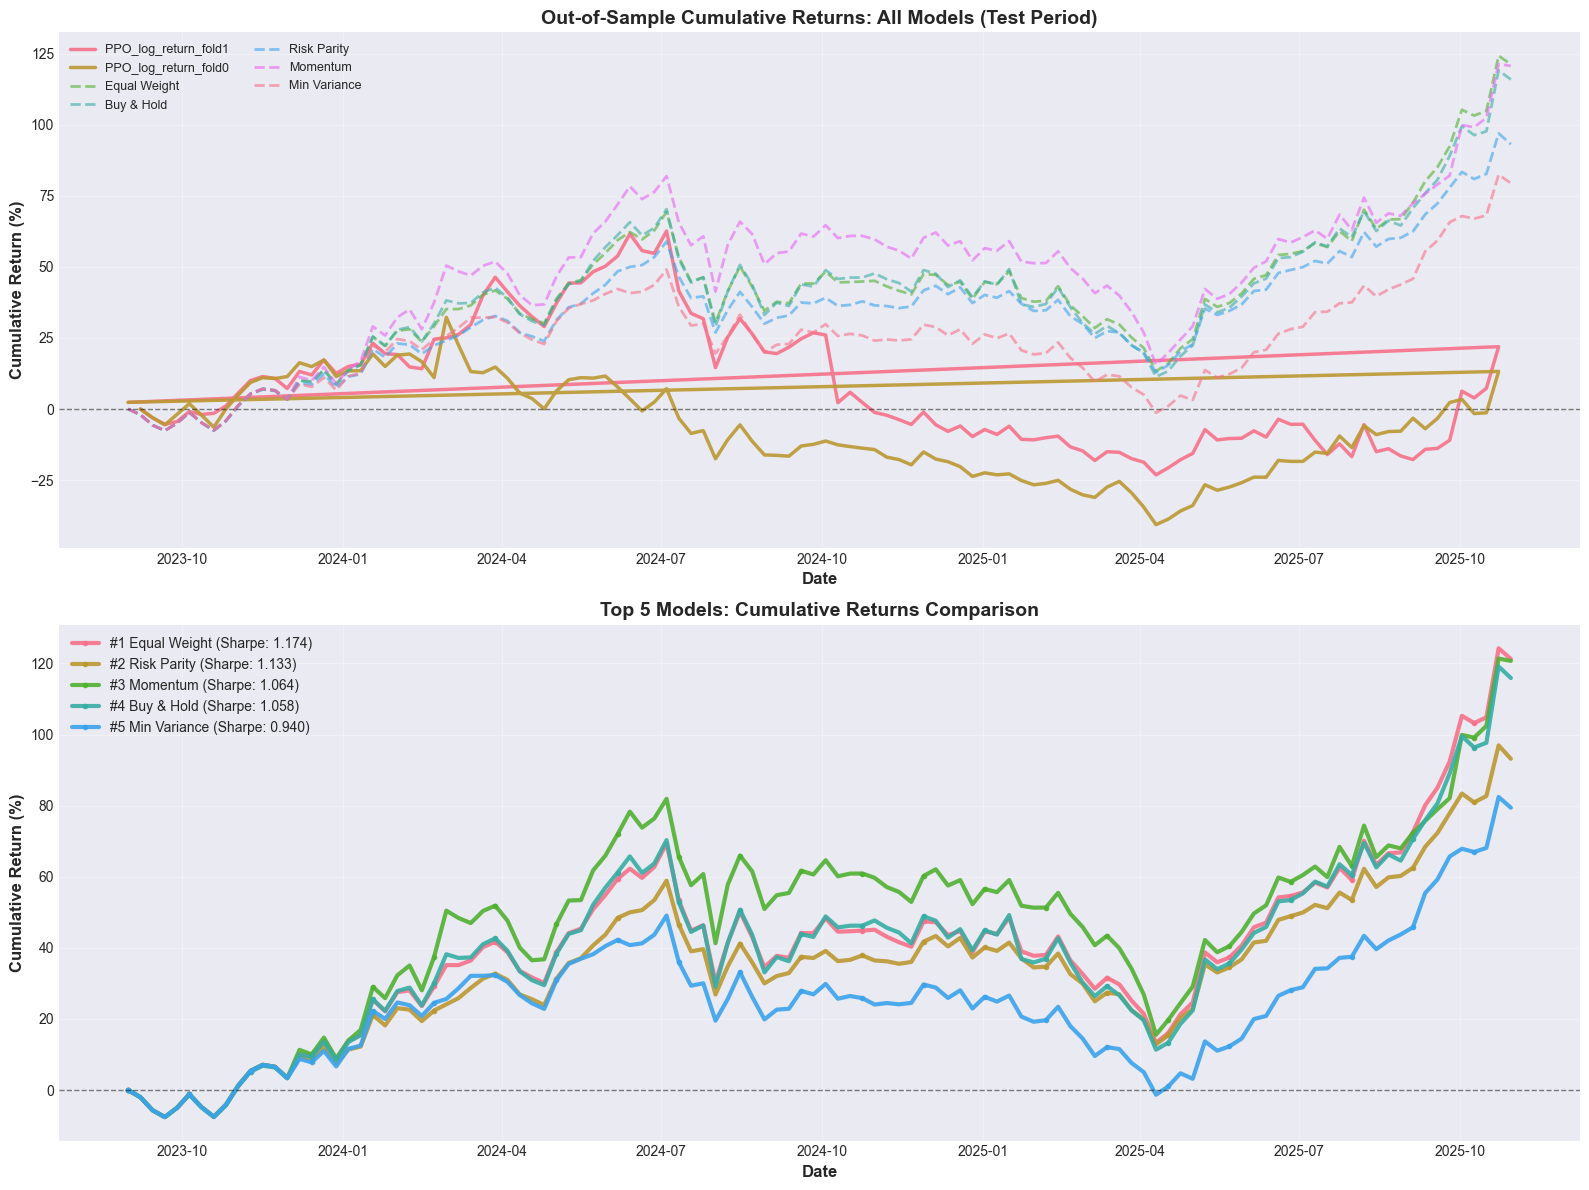


💾 Plot saved: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests/cumulative_returns_all_models.png


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Top plot: All models
ax1 = axes[0]
for name, result in all_results.items():
    traj = result['trajectory']
    returns = np.array(traj['returns'])
    dates_raw = traj['dates']
    values = traj.get('values', None)
    
    # Use portfolio values if available (more accurate)
    if values is not None and len(values) > 1:
        values_array = np.array(values)
        initial_value = values_array[0]
        cum_returns = ((values_array / initial_value) - 1) * 100
        
        # Align dates with values (values include initial state)
        if len(dates_raw) == len(values_array):
            dates = dates_raw
        elif len(dates_raw) == len(values_array) + 1:
            dates = dates_raw[1:]  # Skip first date
        else:
            dates = dates_raw[:len(values_array)]
    else:
        # Fallback to returns-based calculation
        # Ensure dates and returns are aligned (one return per date)
        if len(dates_raw) > len(returns):
            dates = dates_raw[1:len(returns)+1]  # Skip first date, align with returns
        elif len(dates_raw) == len(returns) + 1:
            dates = dates_raw[1:]  # Skip first date
        else:
            dates = dates_raw[:len(returns)]
        
        # Ensure dates and returns are aligned
        min_len = min(len(dates), len(returns))
        dates = dates[:min_len]
        returns = returns[:min_len]
        
        if len(returns) == 0 or len(dates) == 0:
            continue
        
        # Calculate cumulative returns starting from 0
        cum_returns = (np.exp(np.cumsum(returns)) - 1) * 100
    
    # Ensure dates are datetime objects
    if len(dates) > 0:
        if isinstance(dates[0], str):
            dates = pd.to_datetime(dates)
        elif not isinstance(dates[0], pd.Timestamp):
            dates = pd.to_datetime(dates)
    
    # Ensure final alignment
    final_len = min(len(dates), len(cum_returns))
    dates = dates[:final_len]
    cum_returns = cum_returns[:final_len]
    
    if len(cum_returns) == 0 or len(dates) == 0:
        continue
    
    # Style based on model type
    if result.get('model_type') == 'PPO' or name.startswith('PPO_'):
        linewidth = 2.5
        alpha = 0.9
        linestyle = '-'
    else:
        linewidth = 2
        alpha = 0.6
        linestyle = '--'
    
    ax1.plot(dates, cum_returns, label=name, linewidth=linewidth, alpha=alpha, linestyle=linestyle)

ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
ax1.set_title('Out-of-Sample Cumulative Returns: All Models (Test Period)', 
             fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=9, framealpha=0.9, ncol=2)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Bottom plot: Top 5 models only
ax2 = axes[1]
top5_models = summary_df.head(5)['Model'].tolist()

for name in top5_models:
    if name in all_results:
        result = all_results[name]
        traj = result['trajectory']
        returns = np.array(traj['returns'])
        dates_raw = traj['dates']
        values = traj.get('values', None)
        
        # Use portfolio values if available (more accurate)
        if values is not None and len(values) > 1:
            values_array = np.array(values)
            initial_value = values_array[0]
            cum_returns = ((values_array / initial_value) - 1) * 100
            
            # Align dates with values
            if len(dates_raw) == len(values_array):
                dates = dates_raw
            elif len(dates_raw) == len(values_array) + 1:
                dates = dates_raw[1:]
            else:
                dates = dates_raw[:len(values_array)]
        else:
            # Fallback to returns-based calculation
            if len(dates_raw) > len(returns):
                dates = dates_raw[1:len(returns)+1]
            elif len(dates_raw) == len(returns) + 1:
                dates = dates_raw[1:]
            else:
                dates = dates_raw[:len(returns)]
            
            min_len = min(len(dates), len(returns))
            dates = dates[:min_len]
            returns = returns[:min_len]
            
            if len(returns) == 0 or len(dates) == 0:
                continue
            
            cum_returns = (np.exp(np.cumsum(returns)) - 1) * 100
        
        # Ensure dates are datetime objects
        if len(dates) > 0:
            if isinstance(dates[0], str):
                dates = pd.to_datetime(dates)
            elif not isinstance(dates[0], pd.Timestamp):
                dates = pd.to_datetime(dates)
        
        # Final alignment
        final_len = min(len(dates), len(cum_returns))
        dates = dates[:final_len]
        cum_returns = cum_returns[:final_len]
        
        if len(cum_returns) == 0 or len(dates) == 0:
            continue
        
        rank = summary_df[summary_df['Model'] == name]['Rank'].iloc[0]
        sharpe = summary_df[summary_df['Model'] == name]['Test Sharpe'].iloc[0]
        
        ax2.plot(dates, cum_returns, label=f"#{rank} {name} (Sharpe: {sharpe:.3f})", 
                linewidth=3, alpha=0.9, marker='o', markersize=3, markevery=5)

ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
ax2.set_title('Top 5 Models: Cumulative Returns Comparison', 
             fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10, framealpha=0.9)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
cumret_path = OUTPUT_DIR_BACKTEST / 'cumulative_returns_all_models.png'
plt.savefig(cumret_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Plot saved: {cumret_path}")

## 11. Visualization: Risk-Return Analysis

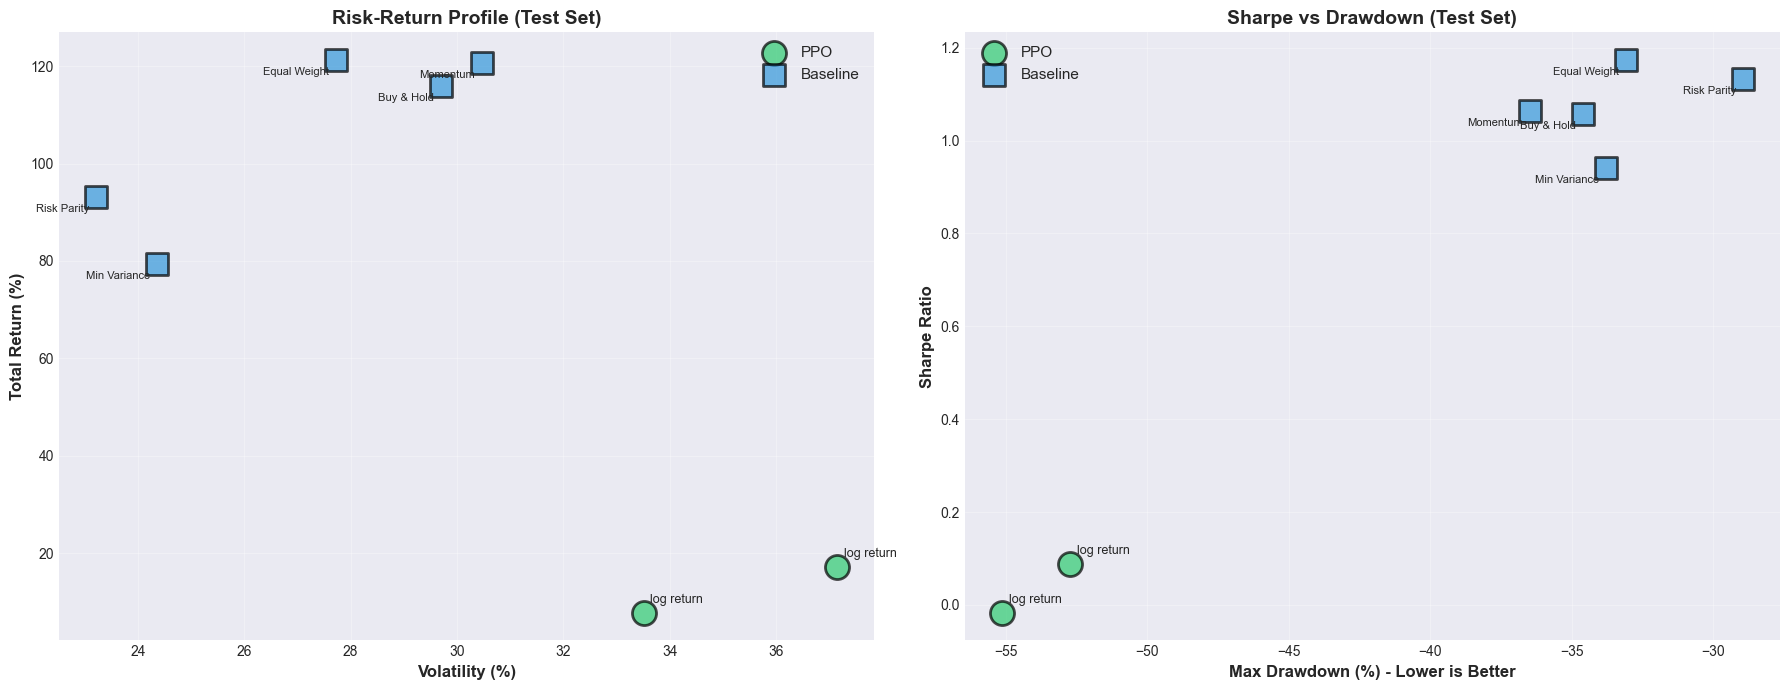


💾 Plot saved: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests/risk_return_analysis.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Risk-Return scatter
ax1 = axes[0]

ppo_data = summary_df[summary_df['Type'] == 'PPO']
baseline_data = summary_df[summary_df['Type'] == 'Baseline']

# Plot PPO models
if len(ppo_data) > 0:
    ax1.scatter(ppo_data['Volatility']*100, ppo_data['Total Return']*100,
                s=300, alpha=0.7, marker='o', c='#2ecc71', edgecolors='black',
                linewidths=2, label='PPO', zorder=3)
    
    for _, row in ppo_data.iterrows():
        ax1.annotate(row['Reward'].replace('_', ' '), 
                     (row['Volatility']*100, row['Total Return']*100),
                     fontsize=9, ha='left', va='bottom', 
                     xytext=(5, 5), textcoords='offset points')

# Plot Baselines
if len(baseline_data) > 0:
    ax1.scatter(baseline_data['Volatility']*100, baseline_data['Total Return']*100,
                s=250, alpha=0.7, marker='s', c='#3498db', edgecolors='black',
                linewidths=2, label='Baseline', zorder=2)
    
    for _, row in baseline_data.iterrows():
        ax1.annotate(row['Model'], 
                     (row['Volatility']*100, row['Total Return']*100),
                     fontsize=8, ha='right', va='top',
                     xytext=(-5, -5), textcoords='offset points')

ax1.set_xlabel('Volatility (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Return (%)', fontsize=12, fontweight='bold')
ax1.set_title('Risk-Return Profile (Test Set)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, alpha=0.3)

# Right: Sharpe vs Drawdown
ax2 = axes[1]

if len(ppo_data) > 0:
    ax2.scatter(ppo_data['Max Drawdown']*100, ppo_data['Test Sharpe'],
                s=300, alpha=0.7, marker='o', c='#2ecc71', edgecolors='black',
                linewidths=2, label='PPO', zorder=3)
    
    for _, row in ppo_data.iterrows():
        ax2.annotate(row['Reward'].replace('_', ' '), 
                     (row['Max Drawdown']*100, row['Test Sharpe']),
                     fontsize=9, ha='left', va='bottom',
                     xytext=(5, 5), textcoords='offset points')

if len(baseline_data) > 0:
    ax2.scatter(baseline_data['Max Drawdown']*100, baseline_data['Test Sharpe'],
                s=250, alpha=0.7, marker='s', c='#3498db', edgecolors='black',
                linewidths=2, label='Baseline', zorder=2)
    
    for _, row in baseline_data.iterrows():
        ax2.annotate(row['Model'], 
                     (row['Max Drawdown']*100, row['Test Sharpe']),
                     fontsize=8, ha='right', va='top',
                     xytext=(-5, -5), textcoords='offset points')

ax2.set_xlabel('Max Drawdown (%) - Lower is Better', fontsize=12, fontweight='bold')
ax2.set_ylabel('Sharpe Ratio', fontsize=12, fontweight='bold')
ax2.set_title('Sharpe vs Drawdown (Test Set)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11, loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
risk_path = OUTPUT_DIR_BACKTEST / 'risk_return_analysis.png'
plt.savefig(risk_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Plot saved: {risk_path}")

## 12. Visualization: PPO Reward Type Comparison

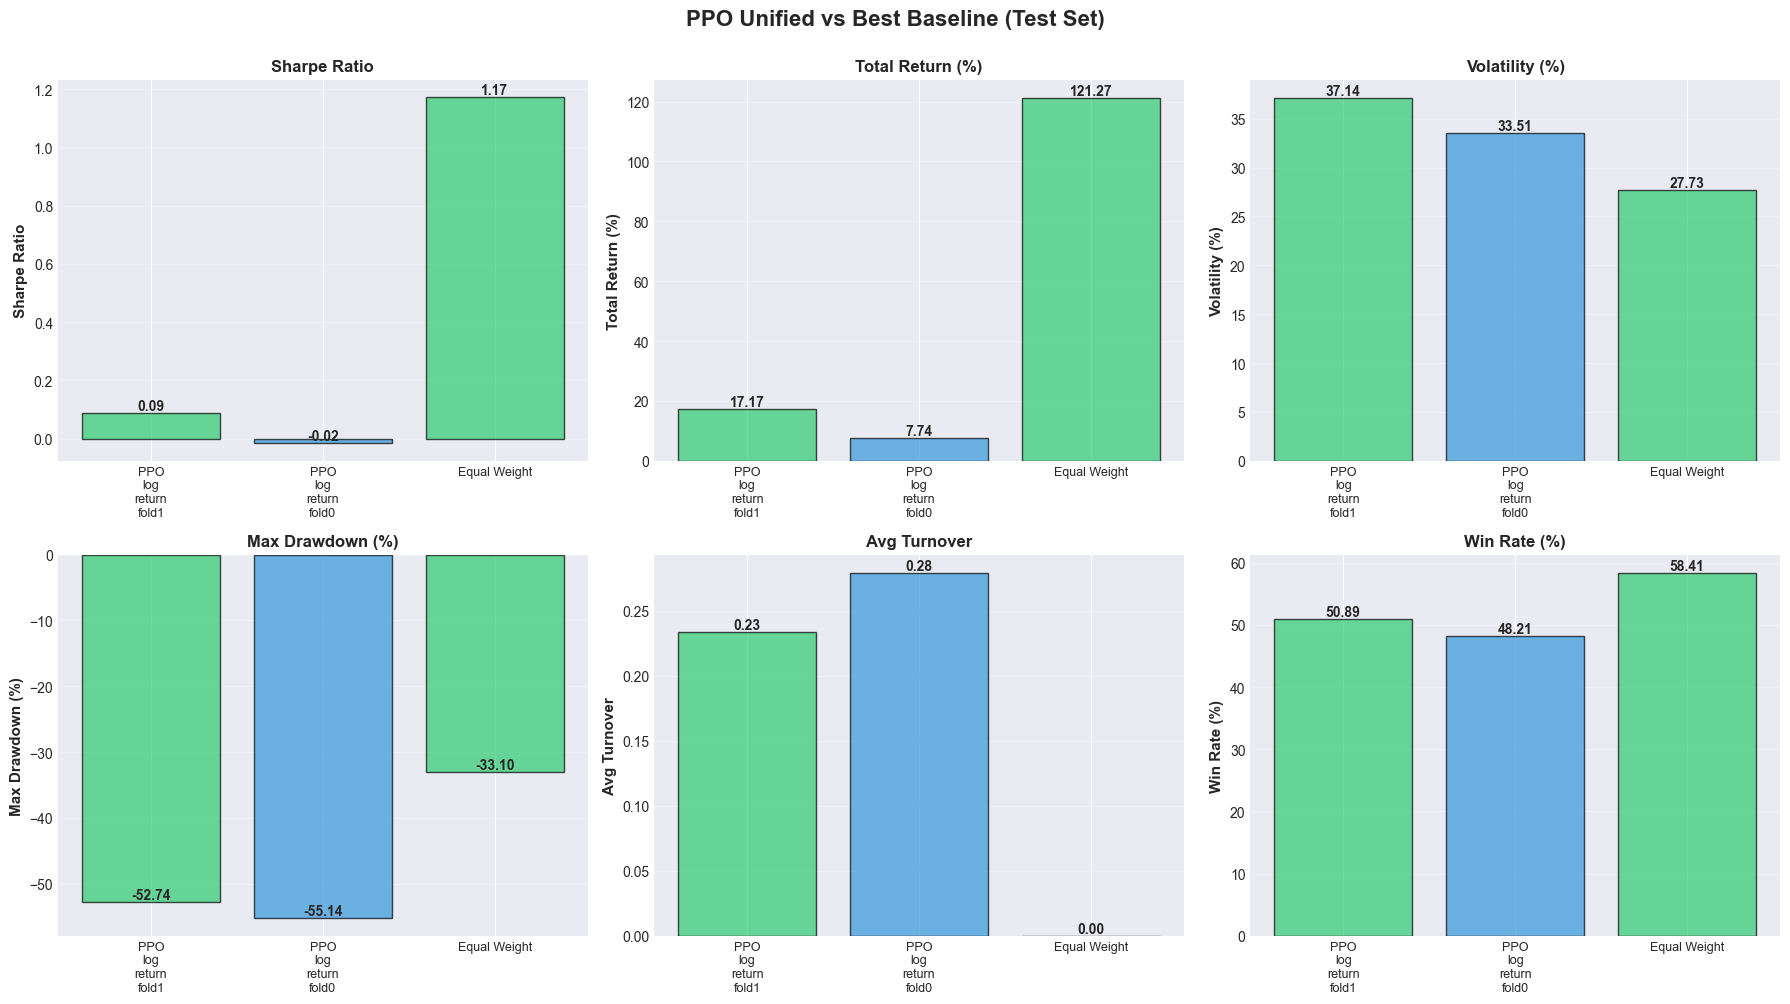


💾 Plot saved: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests/ppo_unified_vs_baseline.png


In [12]:
# PPO reward comparison only makes sense with multiple reward types
# With unified reward, show single model metrics instead

if len(ppo_data) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    metrics = [
        ('Test Sharpe', 'Sharpe Ratio', True),
        ('Total Return', 'Total Return (%)', True),
        ('Volatility', 'Volatility (%)', False),
        ('Max Drawdown', 'Max Drawdown (%)', False),
        ('Avg Turnover', 'Avg Turnover', False),
        ('Win Rate', 'Win Rate (%)', True)
    ]
    
    # Compare PPO unified against best baseline
    if len(baseline_data) > 0:
        best_baseline_name = baseline_data.iloc[0]['Model']
        comparison_df = pd.concat([ppo_data, baseline_data.head(1)])
        
        for idx, (metric, title, higher_better) in enumerate(metrics):
            ax = axes[idx // 3, idx % 3]
            
            values = comparison_df[metric].values
            if metric in ['Total Return', 'Volatility', 'Max Drawdown', 'Win Rate']:
                values = values * 100
            
            labels = comparison_df['Model'].values
            
            # Color bars
            colors = ['#2ecc71', '#3498db']  # PPO green, baseline blue
            
            bars = ax.bar(range(len(labels)), values, color=colors, alpha=0.7, edgecolor='black')
            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels([l.replace('_', '\n').replace('PPO ', 'PPO\n') for l in labels], fontsize=9)
            ax.set_ylabel(title, fontsize=11, fontweight='bold')
            ax.set_title(f'{title}', fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add value labels
            for bar, val in zip(bars, values):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{val:.2f}',
                        ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        plt.suptitle('PPO Unified vs Best Baseline (Test Set)', fontsize=16, fontweight='bold', y=1.00)
    else:
        # Just show PPO metrics
        for idx, (metric, title, higher_better) in enumerate(metrics):
            ax = axes[idx // 3, idx % 3]
            
            value = ppo_data[metric].values[0]
            if metric in ['Total Return', 'Volatility', 'Max Drawdown', 'Win Rate']:
                value = value * 100
            
            bars = ax.bar([0], [value], color='#2ecc71', alpha=0.7, edgecolor='black')
            ax.set_xticks([0])
            ax.set_xticklabels(['PPO Unified'], fontsize=9)
            ax.set_ylabel(title, fontsize=11, fontweight='bold')
            ax.set_title(f'{title}', fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')
            
            ax.text(0, value, f'{value:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        plt.suptitle('PPO Unified Performance (Test Set)', fontsize=16, fontweight='bold', y=1.00)
    
    plt.tight_layout()
    
    ppo_comp_path = OUTPUT_DIR_BACKTEST / 'ppo_unified_vs_baseline.png'
    plt.savefig(ppo_comp_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n💾 Plot saved: {ppo_comp_path}")
else:
    print("⚠️  No PPO results to display")

## 13. Visualization: Model Ranking

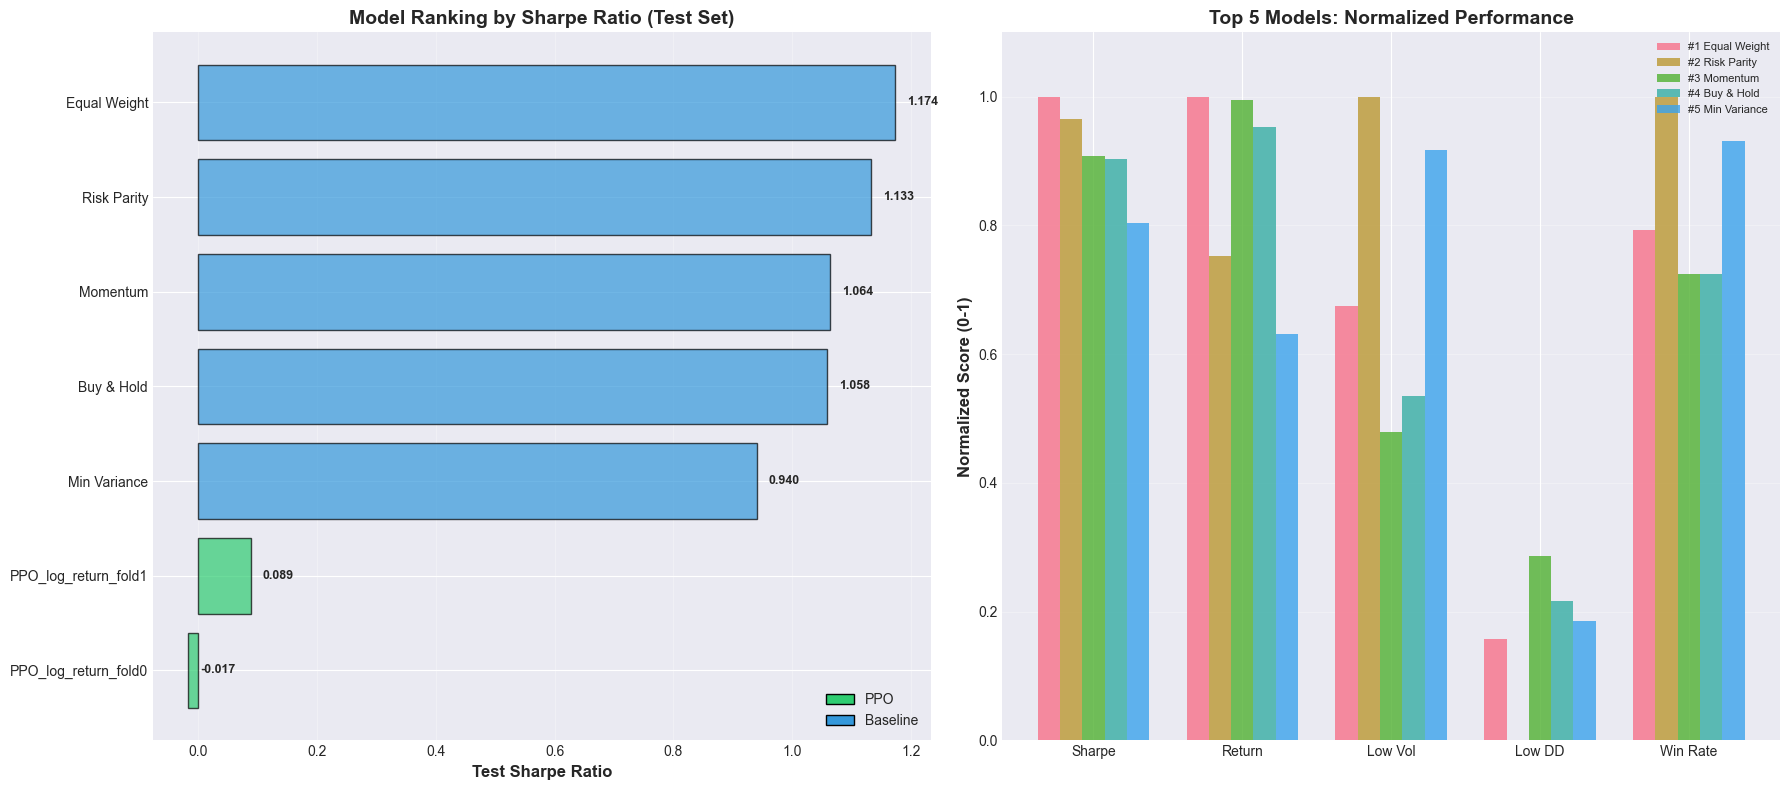


💾 Plot saved: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests/model_ranking.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Sharpe ratio ranking
ax1 = axes[0]
colors = ['#2ecc71' if t == 'PPO' else '#3498db' for t in summary_df['Type']]
bars = ax1.barh(summary_df['Model'], summary_df['Test Sharpe'], color=colors, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Test Sharpe Ratio', fontsize=12, fontweight='bold')
ax1.set_title('Model Ranking by Sharpe Ratio (Test Set)', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, val in zip(bars, summary_df['Test Sharpe']):
    width = bar.get_width()
    ax1.text(width + 0.02, bar.get_y() + bar.get_height()/2.,
            f'{val:.3f}',
            ha='left', va='center', fontsize=9, fontweight='bold')

# Add legend
legend_elements = [Patch(facecolor='#2ecc71', edgecolor='black', label='PPO'),
                   Patch(facecolor='#3498db', edgecolor='black', label='Baseline')]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=10)

# Right: Normalized performance radar
ax2 = axes[1]

# Normalize metrics for top 5 models
top5 = summary_df.head(5)

# Metrics to compare (normalize so higher is always better)
metrics_norm = []
for _, row in top5.iterrows():
    # Normalize each metric to 0-1 range
    sharpe_norm = (row['Test Sharpe'] - summary_df['Test Sharpe'].min()) / \
                  (summary_df['Test Sharpe'].max() - summary_df['Test Sharpe'].min())
    return_norm = (row['Total Return'] - summary_df['Total Return'].min()) / \
                  (summary_df['Total Return'].max() - summary_df['Total Return'].min())
    # Invert for vol and dd (lower is better)
    vol_norm = 1 - ((row['Volatility'] - summary_df['Volatility'].min()) / \
                    (summary_df['Volatility'].max() - summary_df['Volatility'].min()))
    dd_norm = 1 - ((row['Max Drawdown'] - summary_df['Max Drawdown'].min()) / \
                   (summary_df['Max Drawdown'].max() - summary_df['Max Drawdown'].min()))
    wr_norm = (row['Win Rate'] - summary_df['Win Rate'].min()) / \
              (summary_df['Win Rate'].max() - summary_df['Win Rate'].min())
    
    metrics_norm.append([sharpe_norm, return_norm, vol_norm, dd_norm, wr_norm])

x = np.arange(5)
width = 0.15
metric_names = ['Sharpe', 'Return', 'Low Vol', 'Low DD', 'Win Rate']

for i, (_, row) in enumerate(top5.iterrows()):
    offset = (i - 2) * width
    ax2.bar(x + offset, metrics_norm[i], width, 
            label=f"#{i+1} {row['Model']}", alpha=0.8)

ax2.set_ylabel('Normalized Score (0-1)', fontsize=12, fontweight='bold')
ax2.set_title('Top 5 Models: Normalized Performance', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metric_names)
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim([0, 1.1])

plt.tight_layout()
ranking_path = OUTPUT_DIR_BACKTEST / 'model_ranking.png'
plt.savefig(ranking_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Plot saved: {ranking_path}")

## 14. PPO Portfolio Weights Analysis


PPO_log_return_fold1 - Average Weights:
  NVDA:  1.33%
  MU: 31.05%
  AAPL:  8.30%
  AMD: 16.41%
  ASML: 22.52%
  MSFT: 14.14%
  GOOG:  6.25%

PPO_log_return_fold0 - Average Weights:
  NVDA: 12.20%
  MU: 10.25%
  AAPL: 18.47%
  AMD: 29.95%
  ASML: 12.87%
  MSFT: 10.63%
  GOOG:  5.62%


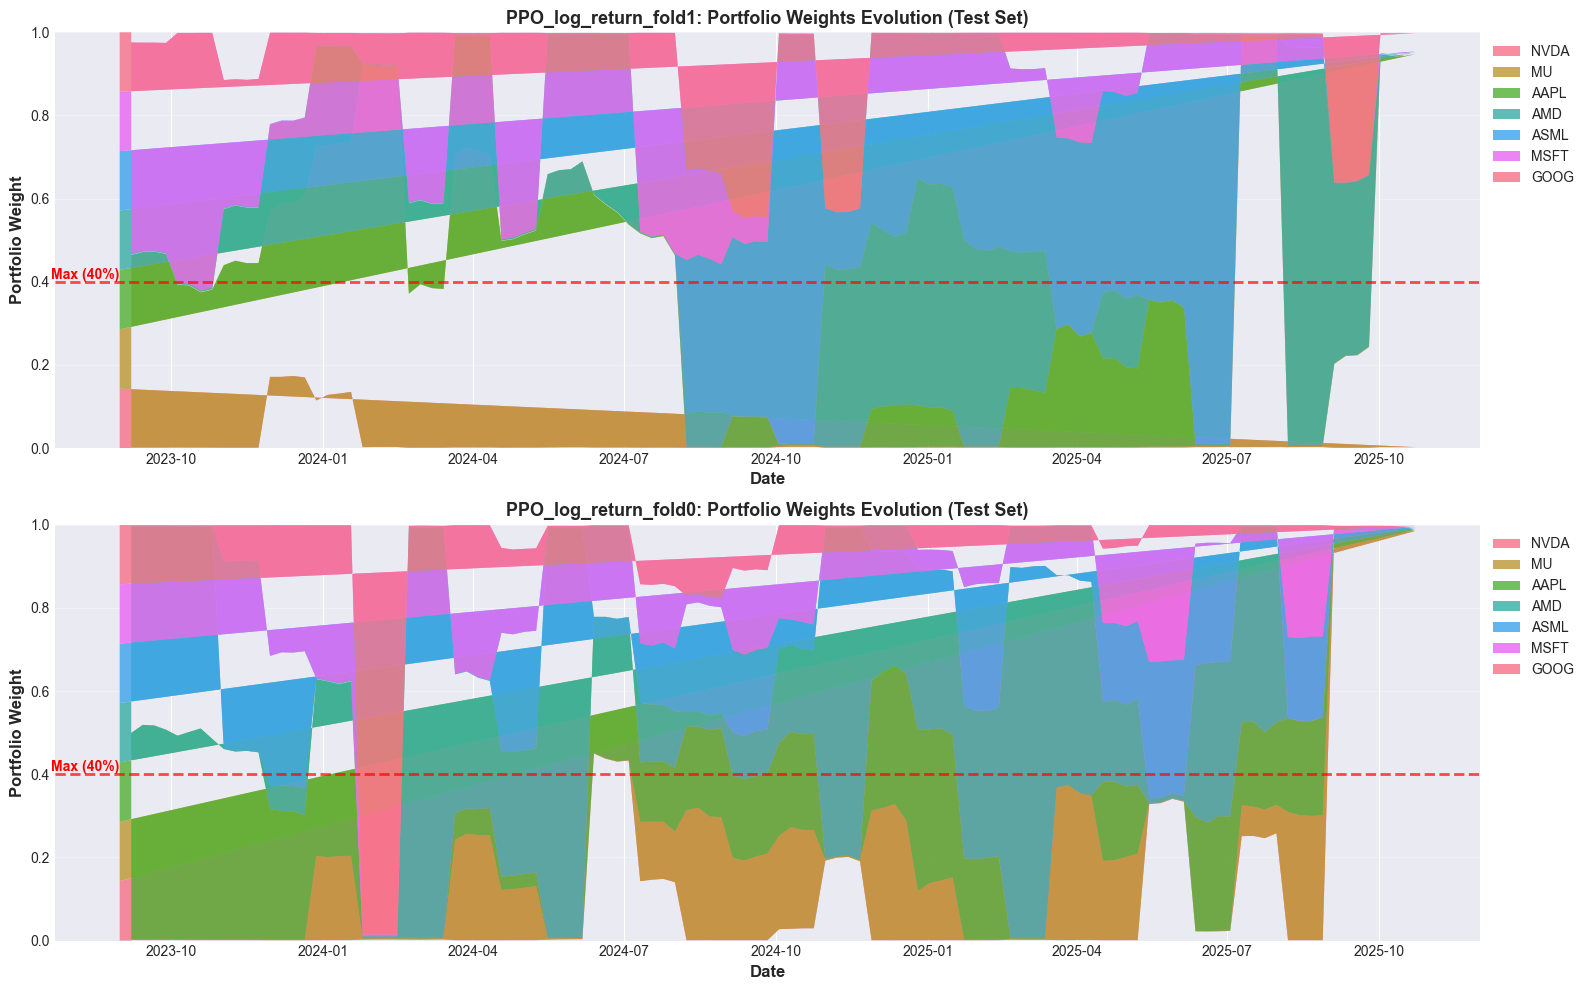


💾 Plot saved: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests/ppo_weights_evolution.png


In [14]:
if len(ppo_results) > 0:
    fig, axes = plt.subplots(len(ppo_results), 1, figsize=(16, 5*len(ppo_results)))
    
    if len(ppo_results) == 1:
        axes = [axes]
    
    for idx, (name, result) in enumerate(ppo_results.items()):
        ax = axes[idx]
        
        weights = np.array(result['trajectory']['weights'])
        dates = result['trajectory']['dates']
        
        # Stacked area chart
        ax.stackplot(dates, weights.T, labels=TICKERS, alpha=0.8)
        
        ax.set_xlabel('Date', fontsize=12, fontweight='bold')
        ax.set_ylabel('Portfolio Weight', fontsize=12, fontweight='bold')
        ax.set_title(f'{name}: Portfolio Weights Evolution (Test Set)', 
                     fontsize=13, fontweight='bold')
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
        ax.set_ylim([0, 1])
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add constraint line
        ax.axhline(y=MAX_WEIGHT_PER_ASSET, color='red', linestyle='--', 
                   linewidth=2, alpha=0.7)
        ax.text(dates[-1], MAX_WEIGHT_PER_ASSET, f'Max ({MAX_WEIGHT_PER_ASSET:.0%})',
                va='bottom', ha='right', fontsize=10, color='red', fontweight='bold')
        
        # Print average weights
        avg_weights = weights.mean(axis=0)
        print(f"\n{name} - Average Weights:")
        for ticker, weight in zip(TICKERS, avg_weights):
            print(f"  {ticker}: {weight:>6.2%}")
    
    plt.tight_layout()
    weights_path = OUTPUT_DIR_BACKTEST / 'ppo_weights_evolution.png'
    plt.savefig(weights_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n💾 Plot saved: {weights_path}")
else:
    print("⚠️  No PPO results available for weight analysis")

## 15. Save All Trajectories

In [15]:
print("\n💾 Saving trajectories...")

for name, result in all_results.items():
    traj = result['trajectory']
    
    # Create dataframe
    df = pd.DataFrame({
        'date': traj['dates'][1:],
        'return': traj['returns'],
        'value': traj['values'][1:]
    })
    
    # Add weights
    weights_df = pd.DataFrame(
        traj['weights'][1:],
        columns=[f'weight_{ticker}' for ticker in TICKERS]
    )
    
    df = pd.concat([df, weights_df], axis=1)
    
    # Save
    safe_name = name.replace(' ', '_').replace('&', 'and').lower()
    df.to_csv(OUTPUT_DIR_BACKTEST / f'trajectory_{safe_name}.csv', index=False)
    print(f"  ✓ {name}: trajectory_{safe_name}.csv")

print(f"\n{'='*100}")
print(f"✅ ALL BACKTESTS COMPLETE!")
print(f"{'='*100}")
print(f"\n📂 All results saved to: {OUTPUT_DIR_BACKTEST}")
print(f"\n📊 Files generated:")
print(f"   - backtest_summary_all_models.csv")
print(f"   - cumulative_returns_all_models.png")
print(f"   - risk_return_analysis.png")
print(f"   - ppo_reward_comparison.png")
print(f"   - model_ranking.png")
print(f"   - ppo_weights_evolution.png")
print(f"   - trajectory_*.csv (one per model)")
print(f"\n🏆 Best Model: {summary_df.iloc[0]['Model']} (Sharpe: {summary_df.iloc[0]['Test Sharpe']:.3f})")


💾 Saving trajectories...
  ✓ PPO_log_return_fold1: trajectory_ppo_log_return_fold1.csv
  ✓ PPO_log_return_fold0: trajectory_ppo_log_return_fold0.csv
  ✓ Equal Weight: trajectory_equal_weight.csv
  ✓ Buy & Hold: trajectory_buy_and_hold.csv
  ✓ Risk Parity: trajectory_risk_parity.csv
  ✓ Momentum: trajectory_momentum.csv
  ✓ Min Variance: trajectory_min_variance.csv

✅ ALL BACKTESTS COMPLETE!

📂 All results saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests

📊 Files generated:
   - backtest_summary_all_models.csv
   - cumulative_returns_all_models.png
   - risk_return_analysis.png
   - ppo_reward_comparison.png
   - model_ranking.png
   - ppo_weights_evolution.png
   - trajectory_*.csv (one per model)

🏆 Best Model: Equal Weight (Sharpe: 1.174)


## Notes

**Test Period:** Completely held-out data not seen during training

**Models Tested:**
- 1 PPO model with unified reward (Sharpe - Drawdown - Turnover)
- 5 Baseline strategies (equal_weight, buy_hold, risk_parity, momentum, min_variance)

**Key Metrics:**
- Sharpe Ratio (risk-adjusted return)
- Total Return (absolute performance)
- Max Drawdown (worst peak-to-trough decline)
- Volatility (return standard deviation)
- Win Rate (% of positive periods)
- Turnover (portfolio rebalancing intensity)

**Unified Reward Function:**
- Primary: Sharpe ratio (risk-adjusted return)
- Penalty: Drawdown coefficient × |max_drawdown|
- Penalty: Turnover coefficient × turnover

**Features:**
- 46 curated features based on factor investing literature
- Categories: Market Regime, Momentum, Trend, Volatility, Risk-Adjusted, Volume, Market Relationship, Seasonality

**Interpretation:**
- Higher Sharpe/Return/Win Rate = Better
- Lower Volatility/Drawdown/Turnover = Better
- PPO uses reinforcement learning with unified reward
- Baselines use traditional portfolio theory

**Next Steps:**
- Analyze performance vs baselines
- Monitor for regime changes
- Consider production deployment if PPO outperforms